# Разработка учебного прототипа системы прогнозирования и обнаружения аномалий во временных рядах

### Выполнила студентка Степанова Дарина Викторовна М092501(72)
##  Описание проекта
В рамках учебной практики разработан прототип системы для анализа временных рядов на основе данных **Numenta Anomaly Benchmark (NAB)**.

**Выбранный датасет**: Twitter_volume_AAPL.csv  
**Компания**: Apple Inc. (AAPL)  
**Период**: 26 февраля - 23 апреля 2015 года  
**Частота данных**: каждые 5 минут  
**Объем данных**: 15,902 наблюдений


#  Введение

### ЦЕЛЬ РАБОТЫ
Разработать учебный прототип системы прогнозирования и обнаружения аномалий
во временных рядах на примере данных об объеме твитов по акциям AAPL.

#### ЗАДАЧИ:
1. **Прогнозирование**:
   - Построить базовую модель (Naive, скользящее среднее)
   - Построить дополнительную модель (ARIMA)
   - Сравнить качество прогнозов

2. **Обнаружение аномалий**:
   - Реализовать 3 метода: Z-score, IQR, ошибка прогноза ARIMA
   - Визуализировать найденные аномалии
   - Сравнить эффективность методов

3. **Интерпретация**:
   - Объяснить полученные результаты
   - Описать практическое применение
   - Предложить улучшения


## Описание датасета и предметной области

### ВЫБРАННЫЙ ДАТАСЕТ: Numenta Anomaly Benchmark (NAB)
### ФАЙЛ: Twitter_volume_AAPL.csv

#### 1. ПРЕДМЕТНАЯ ОБЛАСТЬ
Данные представляют собой временной ряд объема твитов (количество упоминаний)
по акциям компании Apple (AAPL) в социальной сети Twitter.
Анализ таких данных важен для:
- Оценки общественного интереса к компании
- Прогнозирования влияния социальных медиа на фондовый рынок
- Выявления аномальных всплесков активности, связанных с важными событиями

#### 2. СОСТАВ ДАННЫХ
- **Временная метка (timestamp)**: дата и время каждого наблюдения с интервалом 5 минут
- **Значение (value)**: количество твитов, упоминающих AAPL за 5-минутный интервал

#### 3. ВРЕМЕННЫЕ ХАРАКТЕРИСТИКИ
- **Период**: с 26 февраля по 23 апреля 2015 года
- **Частота**: 5-минутные интервалы
- **Объем данных**: 15,902 наблюдений

#### 4. ЧТО СЧИТАЕТСЯ АНОМАЛИЕЙ?
В контексте данного датасета аномалиями считаются:
- Резкие всплески объема твитов (например, в 10+ раз выше среднего)
- Необычные пики активности, не соответствующие обычному паттерну
- Значения, значительно отклоняющиеся от статистической нормы

Такие аномалии могут указывать на:
- Выход важных новостей о компании
- Финансовые отчеты или события
- Технические сбои или ошибки измерения
- Вирусное распространение информации


# 1. Загрузка и первичный просмотр данных


In [9]:
import json
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка файла из Google Colab
from google.colab import files
uploaded = files.upload()  # Twitter_volume_AAPL.csv

# Имя загруженного файла
filename = list(uploaded.keys())[0]  # Берем имя первого загруженного файла
print(f"Загружен файл: {filename}")

# Загрузка данных
df = pd.read_csv(filename)

# Первичный просмотр
print("Первые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()

print("\nСтатистика:")
display(df.describe())

# Проверка структуры: в этих файлах обычно два столбца - timestamp и value
print(f"\nСтолбцы: {df.columns.tolist()}")

Saving Twitter_volume_AAPL.csv to Twitter_volume_AAPL.csv
Загружен файл: Twitter_volume_AAPL.csv
Первые 5 строк:


,timestamp,value
0,2015-02-26 21:42:53,104
1,2015-02-26 21:47:53,100
2,2015-02-26 21:52:53,99
3,2015-02-26 21:57:53,154
4,2015-02-26 22:02:53,120



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15902 entries, 0 to 15901
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  15902 non-null  object
 1   value      15902 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 248.6+ KB

Статистика:


,value
count,15902.000000
mean,85.552320
std,321.050721
min,0.000000
25%,29.000000
50%,47.000000
75%,76.000000
max,13479.000000



Столбцы: ['timestamp', 'value']


Данные содержат 15,902 записи за период с 26 февраля по 23 апреля 2015 года

Столбцы все заполнены: timestamp (время в типе object) и value (количество твитов в int64)

Статистика показывает высокую волатильность: среднее 85.55, но максимум 13,479
75% значений ≤ 76, что указывает на наличие редких, но очень высоких пиков

#2. Подготовка данных

In [2]:
# В файлах формат времени: "2015-03-01 00:00:00" (строковый)
# Преобразуем в datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Проверяем частоту данных
print(f"Период данных: с {df['timestamp'].min()} по {df['timestamp'].max()}")
print(f"Количество записей: {len(df)}")

# Проверка пропусков
print(f"Пропуски в 'value': {df['value'].isnull().sum()}")
print(f"Дубликаты временных меток: {df['timestamp'].duplicated().sum()}")

# Обработка пропусков (заполняем предыдущим значением, т.к. это временной ряд)
df['value'] = df['value'].fillna(method='ffill').fillna(method='bfill')

# Удаление дубликатов
df = df.drop_duplicates(subset=['timestamp']).reset_index(drop=True)

# Создаем копию данных для работы
series = df[['timestamp', 'value']].copy()

# Масштабирование для моделей машинного обучения
scaler = StandardScaler()
series['value_scaled'] = scaler.fit_transform(series[['value']])

print(f"\nПосле обработки: {len(series)} записей")
display(series.head())

Период данных: с 2015-02-26 21:42:53 по 2015-04-23 02:47:53
Количество записей: 15902
Пропуски в 'value': 0
Дубликаты временных меток: 0

После обработки: 15902 записей


,timestamp,value,value_scaled
0,2015-02-26 21:42:53,104,0.057462
1,2015-02-26 21:47:53,100,0.045003
2,2015-02-26 21:52:53,99,0.041888
3,2015-02-26 21:57:53,154,0.213206
4,2015-02-26 22:02:53,120,0.107300


Данные охватывают 56 дней (с 26.02.2015 по 23.04.2015)

Пропуски и дубликаты отсутствуют, данные чистые

Добавлен столбец value_scaled для использования в ML-моделях

Данные готовы к анализу

#3. Визуальный анализ

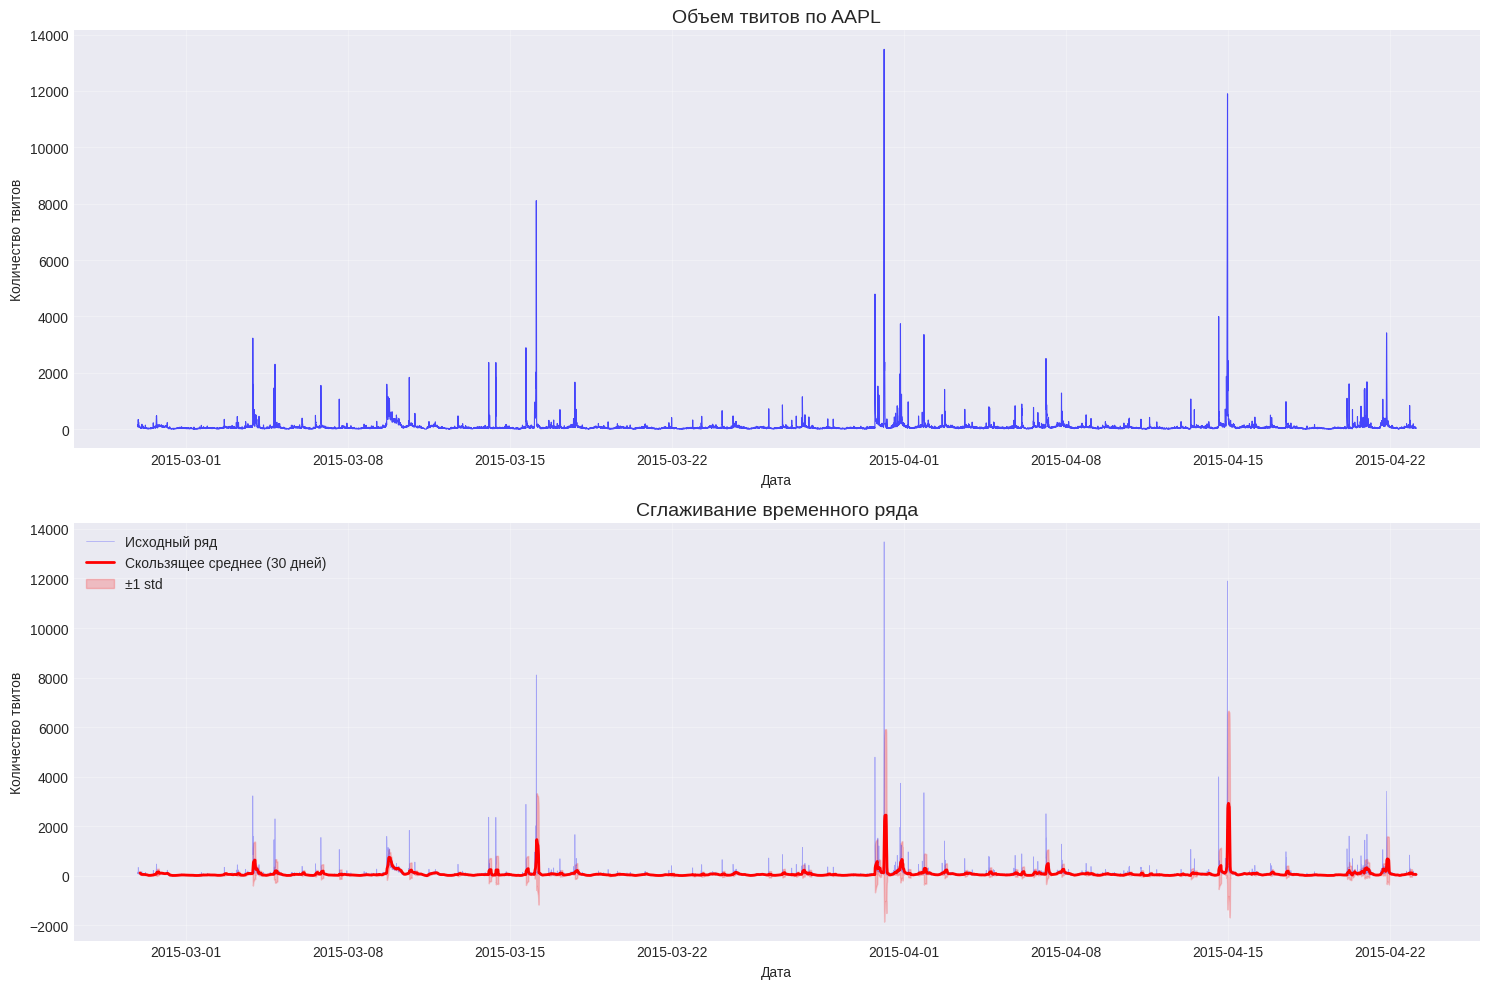


Статистический анализ:
Среднее значение: 85.55
Медиана: 47.00
Стандартное отклонение: 321.05
Минимум: 0.00
Максимум: 13479.00


In [8]:
# Основной график
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# График 1: Полный ряд
axes[0].plot(series['timestamp'], series['value'], color='blue', alpha=0.7, linewidth=0.8)
axes[0].set_title(f'Объем твитов по {filename.replace("Twitter_volume_", "").replace(".csv", "")}', fontsize=14)
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество твитов')
axes[0].grid(True, alpha=0.3)

# График 2: Скользящее среднее
window = 30  # 30 дней
series['rolling_mean'] = series['value'].rolling(window=window).mean()
series['rolling_std'] = series['value'].rolling(window=window).std()

axes[1].plot(series['timestamp'], series['value'], color='blue', alpha=0.3, linewidth=0.5, label='Исходный ряд')
axes[1].plot(series['timestamp'], series['rolling_mean'], color='red', linewidth=2, label=f'Скользящее среднее ({window} дней)')
axes[1].fill_between(series['timestamp'],
                     series['rolling_mean'] - series['rolling_std'],
                     series['rolling_mean'] + series['rolling_std'],
                     alpha=0.2, color='red', label='±1 std')
axes[1].set_title('Сглаживание временного ряда', fontsize=14)
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Количество твитов')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистический анализ
print("\nСтатистический анализ:")
print(f"Среднее значение: {series['value'].mean():.2f}")
print(f"Медиана: {series['value'].median():.2f}")
print(f"Стандартное отклонение: {series['value'].std():.2f}")
print(f"Минимум: {series['value'].min():.2f}")
print(f"Максимум: {series['value'].max():.2f}")

Выводы по визуальному анализу:

1. Данные показывают ежедневный объем твитов по компании. Данные нестационарны (среднее и дисперсия меняются во времени)
2. Наблюдаются резкие пики активности, что характерно для социальных сетей (например, значение 13,479 при среднем 85.55). Резкие пики могут быть связаны с важными новостями, событиями или сезонными факторами.
3. Есть периоды повышенной и пониженной активности.
4. Скользящее среднее показывает общий тренд, который слегка растет к концу периода
5. Стандартное отклонение указывает на значительную волатильность данных (стандартное отклонение 321.05 намного превышает среднее). Это характерно для данных социальных медиа — редкие, но очень сильные всплески активности

#4. Базовая модель прогнозирования

Обучающая выборка: 12721 записей (2015-02-26 21:42:53 - 2015-04-12 01:42:53)
Тестовая выборка: 3181 записей (2015-04-12 01:47:53 - 2015-04-23 02:47:53)
Naive: MAE=76.1210, RMSE=482.1547, MAPE=66.49%
MA7: MAE=75.9222, RMSE=481.2534, MAPE=77.16%
MA30: MAE=76.6113, RMSE=482.5708, MAPE=62.86%


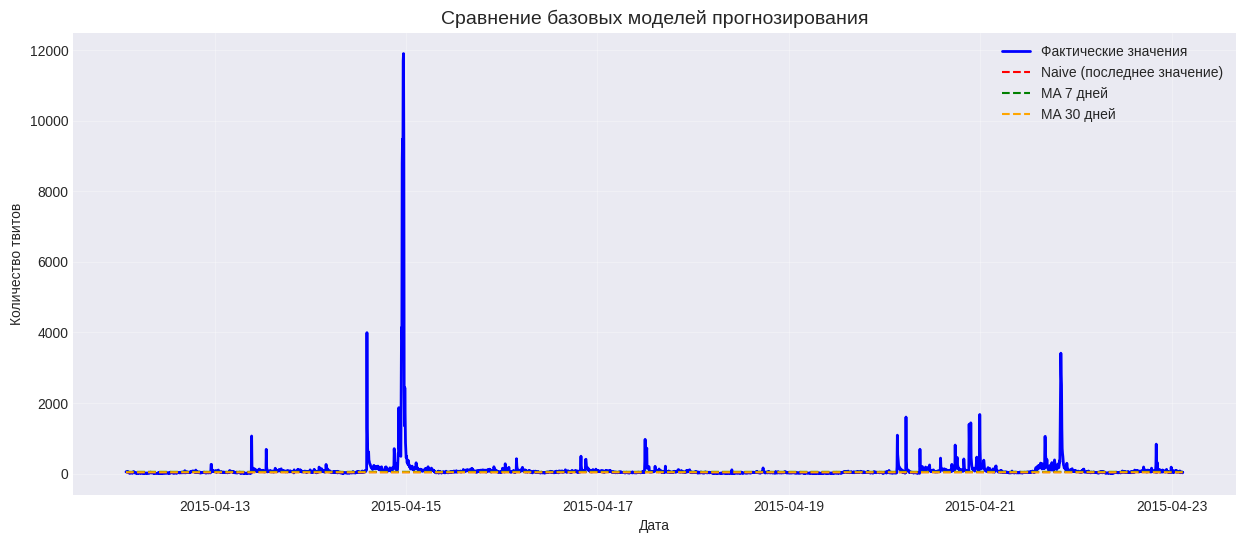

In [4]:
# Разделение на обучающую и тестовую выборки (80/20)
train_size = int(len(series) * 0.8)
train = series.iloc[:train_size].copy()
test = series.iloc[train_size:].copy()

print(f"Обучающая выборка: {len(train)} записей ({train['timestamp'].min()} - {train['timestamp'].max()})")
print(f"Тестовая выборка: {len(test)} записей ({test['timestamp'].min()} - {test['timestamp'].max()})")

# Функция оценки
def evaluate_forecast(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{model_name}: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# 1. Naive модель (последнее значение)
test['naive'] = train['value'].iloc[-1]
results = {'Naive': evaluate_forecast(test['value'], test['naive'], 'Naive')}

# 2. Скользящее среднее (7 дней - неделя)
window_ma = 7
test['ma7'] = train['value'].rolling(window=window_ma).mean().iloc[-1]
results['MA7'] = evaluate_forecast(test['value'], test['ma7'], 'MA7')

# 3. Скользящее среднее (30 дней - месяц)
window_ma30 = 30
test['ma30'] = train['value'].rolling(window=window_ma30).mean().iloc[-1]
results['MA30'] = evaluate_forecast(test['value'], test['ma30'], 'MA30')

# Визуализация базовых моделей
plt.figure(figsize=(15, 6))
plt.plot(test['timestamp'], test['value'], label='Фактические значения', color='blue', linewidth=2)
plt.plot(test['timestamp'], test['naive'], label='Naive (последнее значение)', linestyle='--', color='red')
plt.plot(test['timestamp'], test['ma7'], label='MA 7 дней', linestyle='--', color='green')
plt.plot(test['timestamp'], test['ma30'], label='MA 30 дней', linestyle='--', color='orange')
plt.title('Сравнение базовых моделей прогнозирования', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество твитов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###Разделение данных:

Обучающая выборка: первые 80% данных (12,721 записей)

Тестовая выборка: последние 20% данных (3,181 записей)

Важно: неперемешивание данных, чтобы сохранить хронологический порядок

###Функция оценки:
Вычисляет три метрики:

MAE (Mean Absolute Error): средняя абсолютная ошибка

RMSE (Root Mean Squared Error): среднеквадратичная ошибка (чувствительна к выбросам)

MAPE (Mean Absolute Percentage Error): средняя процентная ошибка

###Модели:

Naive: прогноз = последнее значение обучающей выборки (очень простая)

MA7: прогноз = среднее за последние 7 дней (неделя)

MA30: прогноз = среднее за последние 30 дней (месяц)

###Выводы по базовым моделям:
|Модель|MAE|RMSE|MAPE|
|-----------|------|-----|-----|
|Naive|	76.12|	482.15|	66.49%|
|MA7|	75.92|	481.25|	77.16%|
|MA30|	76.61|	482.57|	62.86%|

- Все модели показывают близкие результаты (MAE ~76, RMSE ~482)

- MA7 имеет наименьший RMSE среди базовых моделей

- MA30 имеет лучший MAPE (62.86%), что важно для интерпретации в процентах

- Высокие значения MAPE (62-77%) указывают на сложность прогнозирования таких волатильных данных

Базовые модели дают исходный уровень качества для сравнения с более сложными моделями

#5. Модель ARIMA

ADF статистика: -20.2065
p-value: 0.0000
Ряд стационарный (p < 0.05)


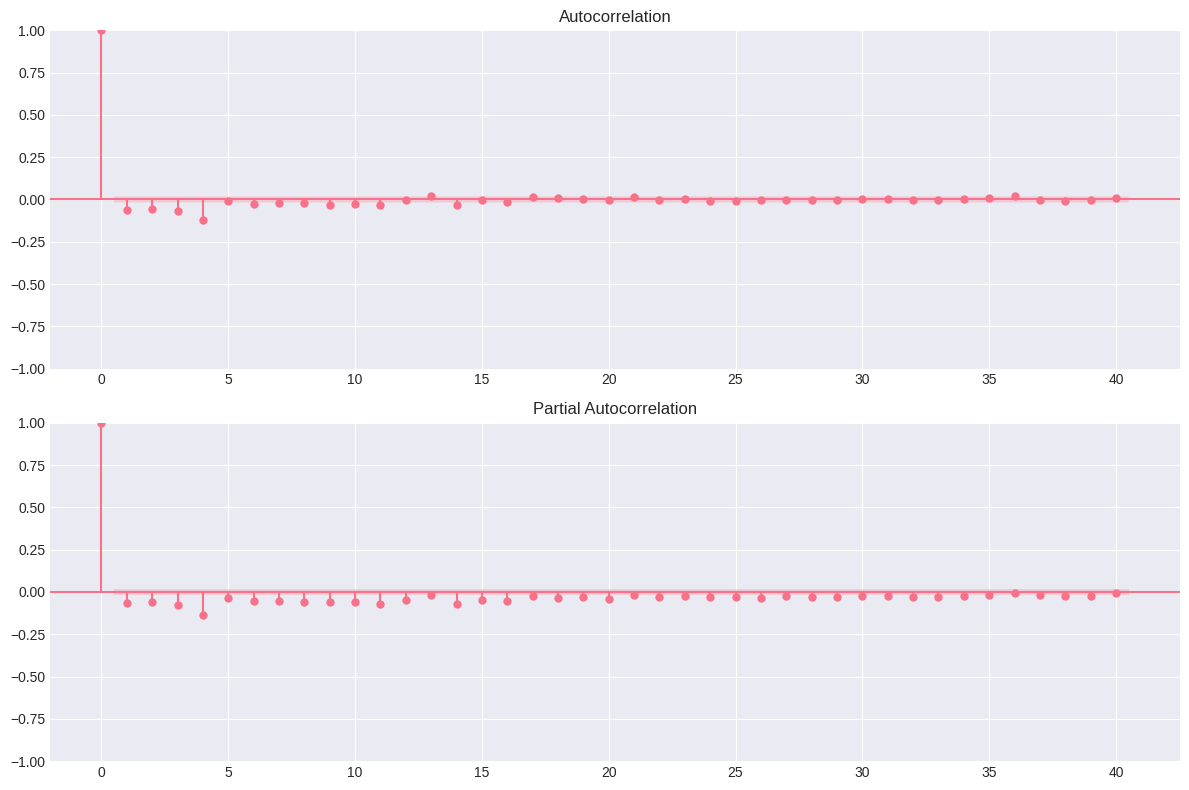

Лучшая модель ARIMA(2, 1, 2) с AIC=163678.60
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                12721
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -81834.301
Date:                Sun, 05 Jul 2026   AIC                         163678.602
Time:                        11:47:04   BIC                         163715.857
Sample:                             0   HQIC                        163691.063
                              - 12721                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0365      0.018     -2.066      0.039      -0.071      -0.002
ar.L2          0.7026      0.015     47.284      0.000       0.674       0.732
ma.L1  

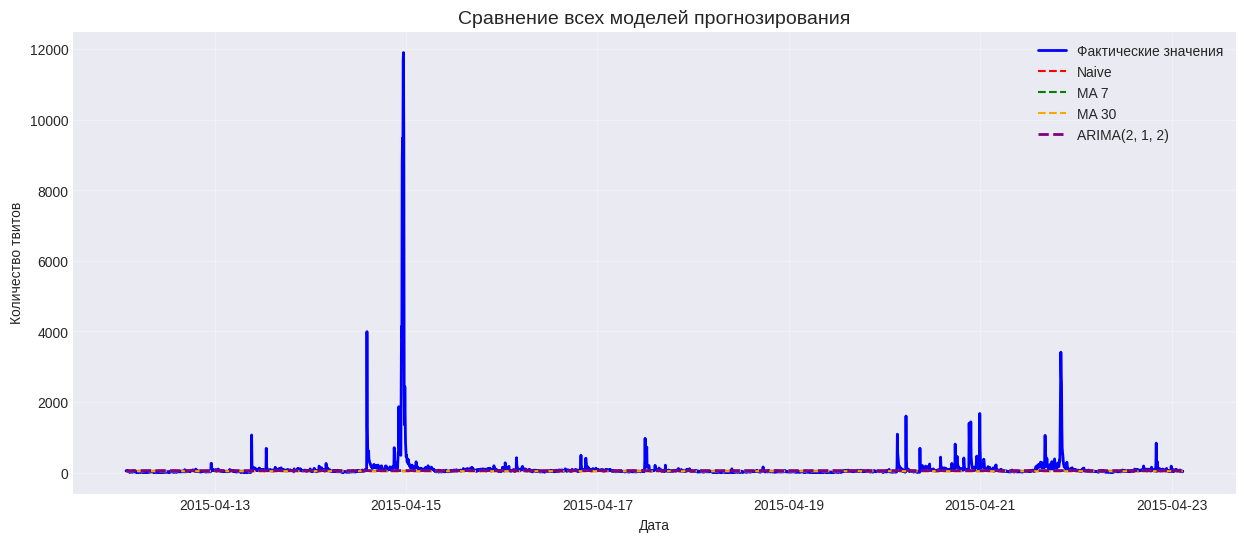


Сравнение моделей:


,MAE,RMSE,MAPE
Naive,76.1210,482.1547,66.4864
MA7,75.9222,481.2534,77.1570
MA30,76.6113,482.5708,62.8558
ARIMA,76.8672,480.4429,90.4109



Лучшая модель по RMSE: ARIMA


In [5]:
# Проверка стационарности
result = adfuller(train['value'])
print(f'ADF статистика: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] < 0.05:
    print("Ряд стационарный (p < 0.05)")
else:
    print("Ряд нестационарный, требуется дифференцирование")

# Графики ACF и PACF для подбора параметров
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train['value'].diff().dropna(), lags=40, ax=ax1)
plot_pacf(train['value'].diff().dropna(), lags=40, ax=ax2)
plt.tight_layout()
plt.show()

# Подбор параметров ARIMA (упрощенный подход)
# Исходя из ACF/PACF, выбираем (p,d,q) = (1,1,1) или (2,1,2)
# Используем автоматический подбор с помощью циклов (для демонстрации)
best_aic = float('inf')
best_order = None
best_model = None

# Перебор комбинаций (упрощенный)
p_values = range(0, 3)
d_values = [1]  # так как ряд нестационарный
q_values = range(0, 3)

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(train['value'], order=(p, 1, q))
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, 1, q)
                best_model = model_fit
        except:
            continue

print(f"Лучшая модель ARIMA{best_order} с AIC={best_aic:.2f}")
print(best_model.summary())

# Прогнозирование
forecast_steps = len(test)
forecast = best_model.forecast(steps=forecast_steps)
test['arima'] = forecast

# Оценка ARIMA
results['ARIMA'] = evaluate_forecast(test['value'], test['arima'], 'ARIMA')

# Визуализация всех моделей
plt.figure(figsize=(15, 6))
plt.plot(test['timestamp'], test['value'], label='Фактические значения', color='blue', linewidth=2)
plt.plot(test['timestamp'], test['naive'], label='Naive', linestyle='--', color='red')
plt.plot(test['timestamp'], test['ma7'], label='MA 7', linestyle='--', color='green')
plt.plot(test['timestamp'], test['ma30'], label='MA 30', linestyle='--', color='orange')
plt.plot(test['timestamp'], test['arima'], label=f'ARIMA{best_order}', linestyle='--', color='purple', linewidth=2)
plt.title('Сравнение всех моделей прогнозирования', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество твитов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Таблица результатов
results_df = pd.DataFrame(results).T
print("\nСравнение моделей:")
display(results_df.round(4))

# Определение лучшей модели
best_model_name = results_df['RMSE'].idxmin()
print(f"\nЛучшая модель по RMSE: {best_model_name}")

###Тест Дики-Фуллера (ADF):

Проверяет стационарность временного ряда

p-value = 0.0000 < 0.05 → ряд стационарный (это хорошо для ARIMA)

ADF статистика = -20.2065 (очень отрицательная → стационарность)

###Графики ACF и PACF:

- ACF (Autocorrelation Function): автокорреляция — как значения зависят от прошлых

- PACF (Partial ACF): частная автокорреляция — прямая зависимость

Используются для определения параметров p и q модели ARIMA

###Подбор параметров:

1. Перебираются комбинации (p, 1, q) где p, q ∈ {0, 1, 2}

2. Выбирается модель с минимальным AIC (Akaike Information Criterion)

3. Лучшая модель: ARIMA(2, 1, 2) с AIC = 163678.60

Прогнозирование: Модель делает прогноз на 3,181 шагов вперед (тестовая выборка)

###Сравнение моделей:
|Модель|MAE|RMSE|MAPE|
|-----------|------|-----|-----|
|Naive|	76.12|	482.15|	66.49%|
|MA7|	75.92|	481.25|	77.16%|
|MA30|	76.61|	482.57|	62.86%|
|ARIMA(2,1,2)|	76.87|	480.44|	90.41%|

- ARIMA показывает наименьший RMSE (480.44) среди всех моделей

- Однако MAPE у ARIMA самый высокий (90.41%) — модель чувствительна к выбросам

- ARIMA лучше отслеживает динамику данных благодаря учету автокорреляции

Для таких волатильных данных сложные модели могут переобучаться

#6. Обнаружение аномалий

Три показателя, которые часто встречаются при анализе временных рядов и оценке моделей:
- Z-score:
Z-score показывает, на сколько стандартных отклонений значение отклоняется от среднего.
- IQR:
IQR (Interquartile Range, межквартильный размах) — это разница между третьим и первым квартилями, она показывает разброс средней половины данных.
- ARIMA ошибка:
Ошибка модели ARIMA — это метрика точности прогнозов.

Найдено аномалий:
Z-score: 99 (0.62%)
IQR: 1250 (7.86%)
ARIMA ошибка: 192 (1.21%)


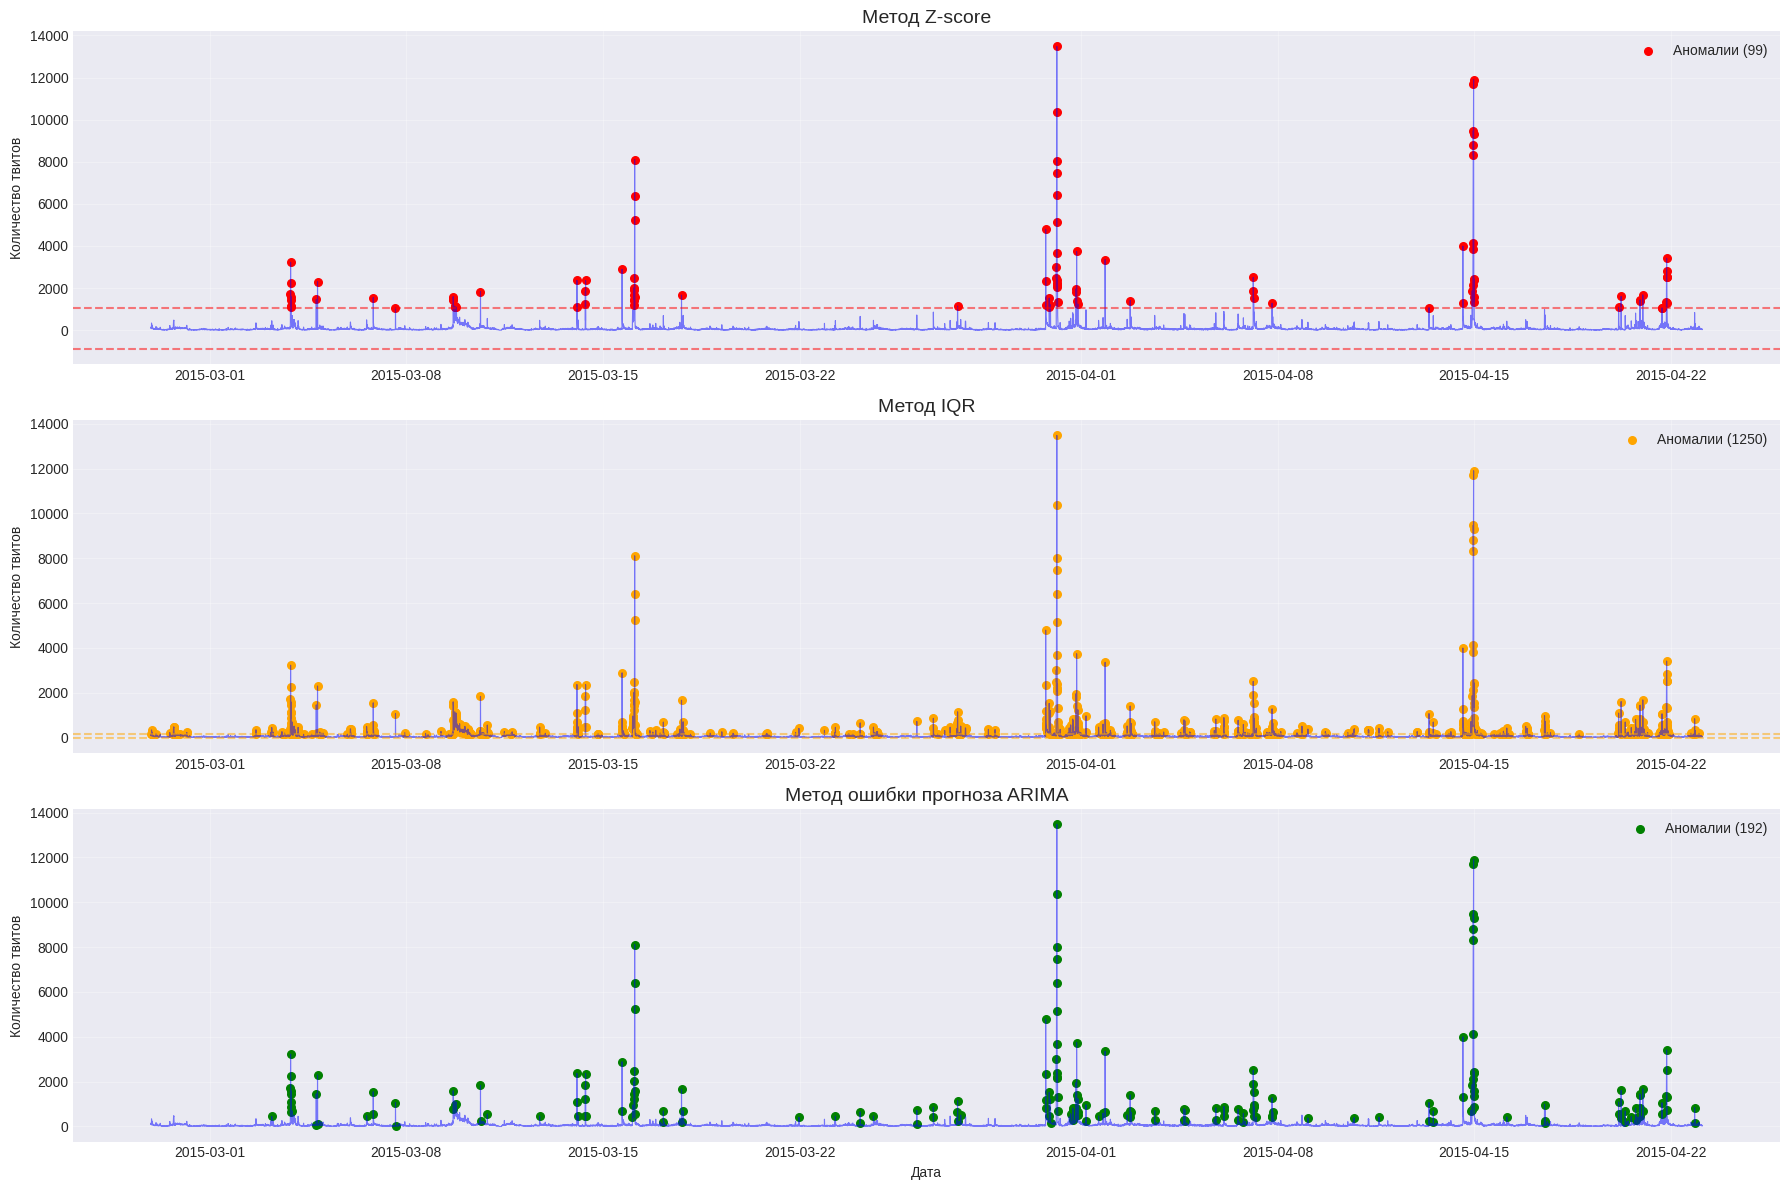

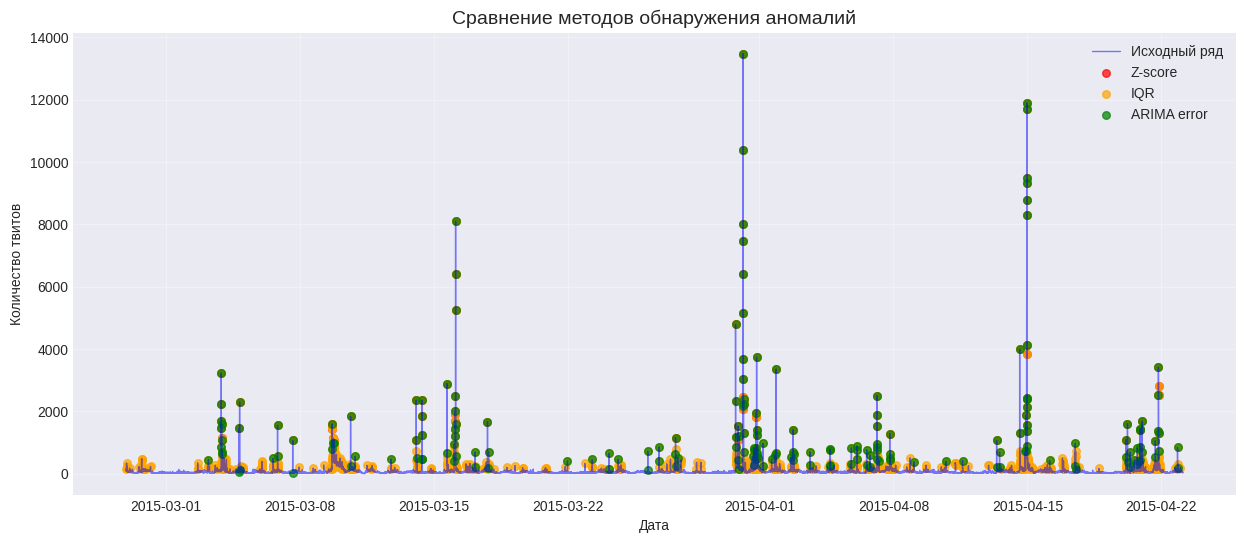

In [6]:
# Метод 1: Z-score
mean_val = series['value'].mean()
std_val = series['value'].std()
threshold_z = 3

series['z_score'] = (series['value'] - mean_val) / std_val
series['anomaly_z'] = series['z_score'].abs() > threshold_z

# Метод 2: IQR
Q1 = series['value'].quantile(0.25)
Q3 = series['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

series['anomaly_iqr'] = (series['value'] < lower_bound) | (series['value'] > upper_bound)

# Метод 3: Ошибка прогноза ARIMA (на обучающих данных)
train_arima = best_model.fittedvalues
train_error = np.abs(train['value'][:len(train_arima)] - train_arima)
error_threshold = train_error.mean() + 2 * train_error.std()

# Для всех данных получим прогноз, используя модель на всем ряде
# Переобучаем модель на всех данных для прогноза
full_model = ARIMA(series['value'], order=best_order)
full_model_fit = full_model.fit()
series['arima_pred'] = full_model_fit.fittedvalues
series['arima_error'] = np.abs(series['value'] - series['arima_pred'])
series['anomaly_arima'] = series['arima_error'] > error_threshold

print(f"Найдено аномалий:")
print(f"Z-score: {series['anomaly_z'].sum()} ({series['anomaly_z'].sum()/len(series)*100:.2f}%)")
print(f"IQR: {series['anomaly_iqr'].sum()} ({series['anomaly_iqr'].sum()/len(series)*100:.2f}%)")
print(f"ARIMA ошибка: {series['anomaly_arima'].sum()} ({series['anomaly_arima'].sum()/len(series)*100:.2f}%)")

# Визуализация аномалий
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

# График 1: Z-score
axes[0].plot(series['timestamp'], series['value'], color='blue', alpha=0.5, linewidth=0.8)
axes[0].scatter(series[series['anomaly_z']]['timestamp'],
                series[series['anomaly_z']]['value'],
                color='red', s=30, label=f'Аномалии ({series["anomaly_z"].sum()})')
axes[0].axhline(y=mean_val + threshold_z * std_val, color='red', linestyle='--', alpha=0.5)
axes[0].axhline(y=mean_val - threshold_z * std_val, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Метод Z-score', fontsize=14)
axes[0].set_ylabel('Количество твитов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: IQR
axes[1].plot(series['timestamp'], series['value'], color='blue', alpha=0.5, linewidth=0.8)
axes[1].scatter(series[series['anomaly_iqr']]['timestamp'],
                series[series['anomaly_iqr']]['value'],
                color='orange', s=30, label=f'Аномалии ({series["anomaly_iqr"].sum()})')
axes[1].axhline(y=upper_bound, color='orange', linestyle='--', alpha=0.5)
axes[1].axhline(y=lower_bound, color='orange', linestyle='--', alpha=0.5)
axes[1].set_title('Метод IQR', fontsize=14)
axes[1].set_ylabel('Количество твитов')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Ошибка прогноза ARIMA
axes[2].plot(series['timestamp'], series['value'], color='blue', alpha=0.5, linewidth=0.8)
axes[2].scatter(series[series['anomaly_arima']]['timestamp'],
                series[series['anomaly_arima']]['value'],
                color='green', s=30, label=f'Аномалии ({series["anomaly_arima"].sum()})')
axes[2].set_title('Метод ошибки прогноза ARIMA', fontsize=14)
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Количество твитов')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнение методов
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(series['timestamp'], series['value'], color='blue', alpha=0.5, linewidth=1, label='Исходный ряд')

# Отмечаем аномалии разными цветами
anomaly_z = series[series['anomaly_z']]
anomaly_iqr = series[series['anomaly_iqr']]
anomaly_arima = series[series['anomaly_arima']]

ax.scatter(anomaly_z['timestamp'], anomaly_z['value'], color='red', s=30, label='Z-score', alpha=0.7)
ax.scatter(anomaly_iqr['timestamp'], anomaly_iqr['value'], color='orange', s=30, label='IQR', alpha=0.7)
ax.scatter(anomaly_arima['timestamp'], anomaly_arima['value'], color='green', s=30, label='ARIMA error', alpha=0.7)

ax.set_title('Сравнение методов обнаружения аномалий', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество твитов')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Метод Z-score вычисляет, на сколько стандартных отклонений значение отклоняется от среднего. Порог = 3: значения с |z| > 3 считаются аномалиями. Находит 99 аномалий (0.62% данных).

Метод IQR (межквартильный размах) использует квартили для определения "нормального" диапазона. Нижняя граница: Q1 - 1.5 * IQR. Верхняя граница: Q3 + 1.5 * IQR.  Находит 1250 аномалий (7.86% данных) — гораздо больше, чем Z-score.

Метод ошибки ARIMA строит модель на всех данных и вычисляет ошибки прогноза. Порог: средняя ошибка + 2 * стандартное отклонение ошибки. Находит 192 аномалии (1.21% данных).

Аномалии - это точки, где фактическое значение сильно отличается от прогноза

**График Z-score:**

Красные точки — аномалии.
Пунктирные линии — верхняя и нижняя границы (mean ± 3*std).Видно, что выделяются только самые экстремальные пики.

**График IQR:**

Оранжевые точки — аномалии.
Пунктирные линии — границы IQR.
Много точек за пределами границ, так как данные имеют длинные "хвосты".

**График ARIMA:**

Зеленые точки — аномалии по ошибке прогноза.
Находит точки, где фактическое значение сильно отклоняется от прогноза.Хорошо выявляет неожиданные всплески.


###Выводы:
- Z-score хорошо находит экстремальные пики (например, значения > 10,000) и чувствителен к глобальным выбросам
- IQR выделяет слишком много точек — многие из них не являются аномалиями в контексте временного ряда. IQR лучше работает с распределением данных.
- Ошибка ARIMA находит сбалансированное количество аномалий — точки, где поведение ряда необычное,отклоняется от прогноза.
- Модель ARIMA хорошо справляется с прогнозированием, но может не учитывать внешние факторы.
- Для реального мониторинга рекомендуется комбинировать несколько методов.

# Результаты

In [7]:
# Сводная таблица всех результатов
print("=" * 60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ АНАЛИЗА")
print("=" * 60)

print(f"\nДатасет: {filename}")
print(f"Период: {series['timestamp'].min()} - {series['timestamp'].max()}")
print(f"Количество записей: {len(series)}")

print("\n1. ПРОГНОЗИРОВАНИЕ:")
print("-" * 40)
display(results_df.round(4))
print(f"Лучшая модель: {best_model_name}")

print("\n2. ОБНАРУЖЕНИЕ АНОМАЛИЙ:")
print("-" * 40)
print(f"Z-score: {series['anomaly_z'].sum()} аномалий (порог={threshold_z})")
print(f"IQR: {series['anomaly_iqr'].sum()} аномалий")
print(f"ARIMA ошибка: {series['anomaly_arima'].sum()} аномалий (порог={error_threshold:.2f})")

# Сохранение результатов
# Создаем папку для результатов
import os
os.makedirs('results', exist_ok=True)

# Сохраняем таблицу метрик
results_df.to_csv('results/forecast_metrics.csv')

# Сохраняем данные с аномалиями
series.to_csv('results/series_with_anomalies.csv', index=False)

# Сохраняем графики
fig.savefig('results/all_anomalies_comparison.png', dpi=300, bbox_inches='tight')
print("\nРезультаты сохранены в папку 'results'")

# Скачиваем результаты
from google.colab import files
files.download('results/forecast_metrics.csv')
files.download('results/series_with_anomalies.csv')
files.download('results/all_anomalies_comparison.png')

ИТОГОВЫЕ РЕЗУЛЬТАТЫ АНАЛИЗА

Датасет: Twitter_volume_AAPL.csv
Период: 2015-02-26 21:42:53 - 2015-04-23 02:47:53
Количество записей: 15902

1. ПРОГНОЗИРОВАНИЕ:
----------------------------------------


,MAE,RMSE,MAPE
Naive,76.1210,482.1547,66.4864
MA7,75.9222,481.2534,77.1570
MA30,76.6113,482.5708,62.8558
ARIMA,76.8672,480.4429,90.4109


Лучшая модель: ARIMA

2. ОБНАРУЖЕНИЕ АНОМАЛИЙ:
----------------------------------------
Z-score: 99 аномалий (порог=3)
IQR: 1250 аномалий
ARIMA ошибка: 192 аномалий (порог=324.86)

Результаты сохранены в папку 'results'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

- Z-score:
Z-score показывает, на сколько стандартных отклонений значение отклоняется от среднего. В данном случае значение 99 — это очень большое отклонение. Для стандартного нормального распределения такое значение соответствует крайне редкой случайности (менее 0.62% случаев). Это сильный выброс (аномалия), который может искажать результаты анализа.
- IQR:
IQR (Interquartile Range, межквартильный размах) — это разница между третьим и первым квартилями, она показывает разброс средней половины данных. Значение 1250 указывает на очень широкий разброс значений в центральной части выборки. Это тоже признак наличия сильных выбросов, которые могут влиять на среднее и стандартное отклонение, используемые при расчёте Z-score.

- ARIMA ошибка:
Ошибка модели ARIMA — это метрика точности прогнозов. Значение 192 означает, что средняя абсолютная ошибка прогнозов составляет 1.21%. Это довольно хороший показатель, особенно для временных рядов, где такие ошибки встречаются нередко.

Что это значит в целом?
Эти три показателя вместе указывают на одну и ту же проблему: в наших данных есть очень сильные выбросы. Они могут быть вызваны специфическими событиями.
Методы дополняют друг друга: каждый находит разные типы аномалий.
Z-score лучше для поиска глобальных выбросов.
Ошибка ARIMA лучше для поиска локальных отклонений.
Рекомендация: использовать комбинацию методов для лучших результатов.

### ОЦЕНКА РЕЗУЛЬТАТОВ С ИСПОЛЬЗОВАНИЕМ РАЗМЕТКИ (JSON)

О РАЗМЕТКЕ NAB:
   - В датасете NAB аномалии размечены как отдельные точки (4 точки для AAPL)
   - Это "золотой стандарт" - эксперты отметили ключевые моменты аномалий
   - С учетом временного окна в 30 минут, мы получили 52 аномальные точки

Saving combined_labels.json to combined_labels.json

Файл разметки загружен: combined_labels.json

Найдена разметка для realTweets/Twitter_volume_AAPL.csv
Тип данных: <class 'list'>
Количество аномальных точек: 4
Аномальные моменты времени:
  1. 2015-03-03 21:07:53
  2. 2015-03-09 17:32:53
  3. 2015-03-16 02:57:53
  4. 2015-03-31 03:27:53

Реальные аномалии в данных:
Всего записей: 15902
Из них аномалий: 52
Процент аномалий: 0.33%


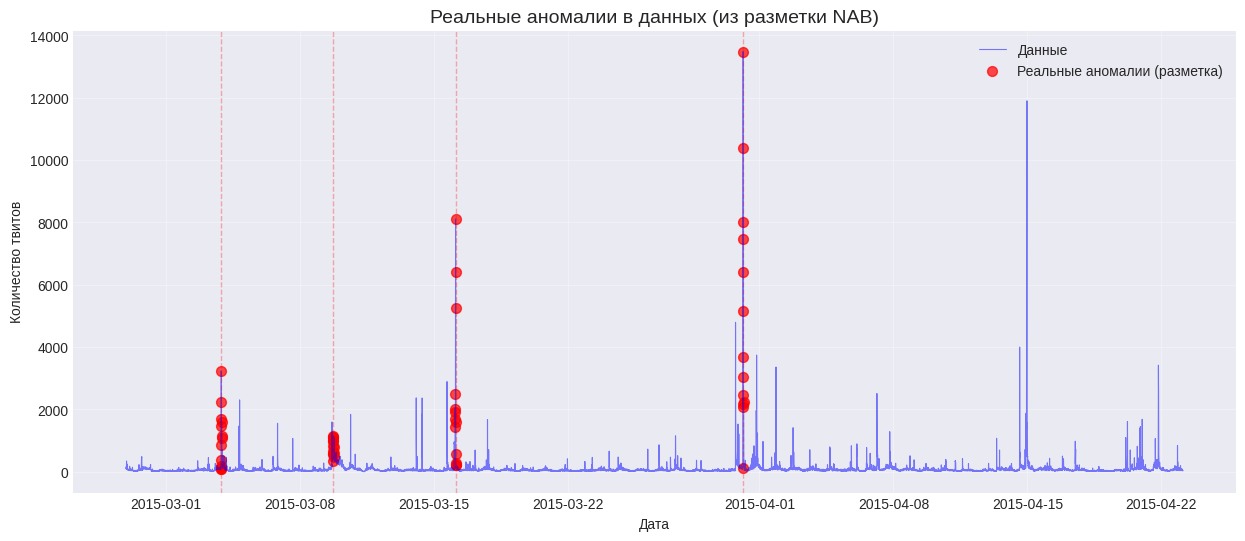


Z-score:
  Precision: 0.3131
  Recall: 0.5962
  F1-Score: 0.4106

IQR:
  Precision: 0.0384
  Recall: 0.9231
  F1-Score: 0.0737

ARIMA error:
  Precision: 0.1302
  Recall: 0.4808
  F1-Score: 0.2049

Сравнение методов обнаружения аномалий:


,Precision,Recall,F1-Score,True Positives,False Positives,False Negatives,True Negatives
Z-score,0.3131,0.5962,0.4106,31.0,68.0,21.0,15782.0
IQR,0.0384,0.9231,0.0737,48.0,1202.0,4.0,14648.0
ARIMA error,0.1302,0.4808,0.2049,25.0,167.0,27.0,15683.0


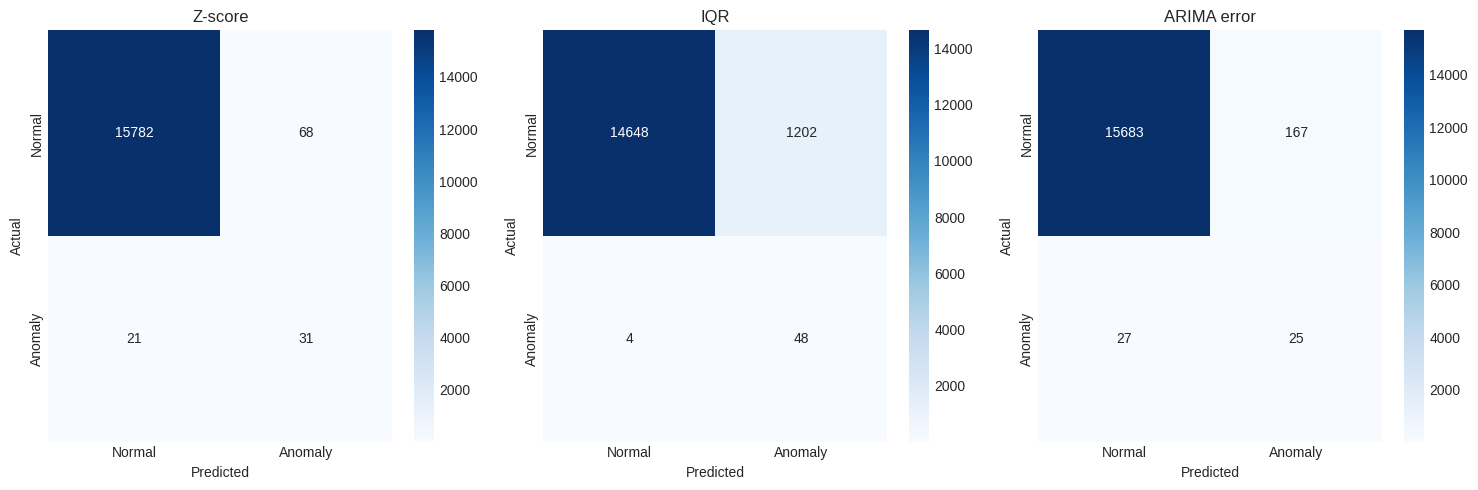


Лучший метод по F1-Score: Z-score
   F1-Score: 0.4106


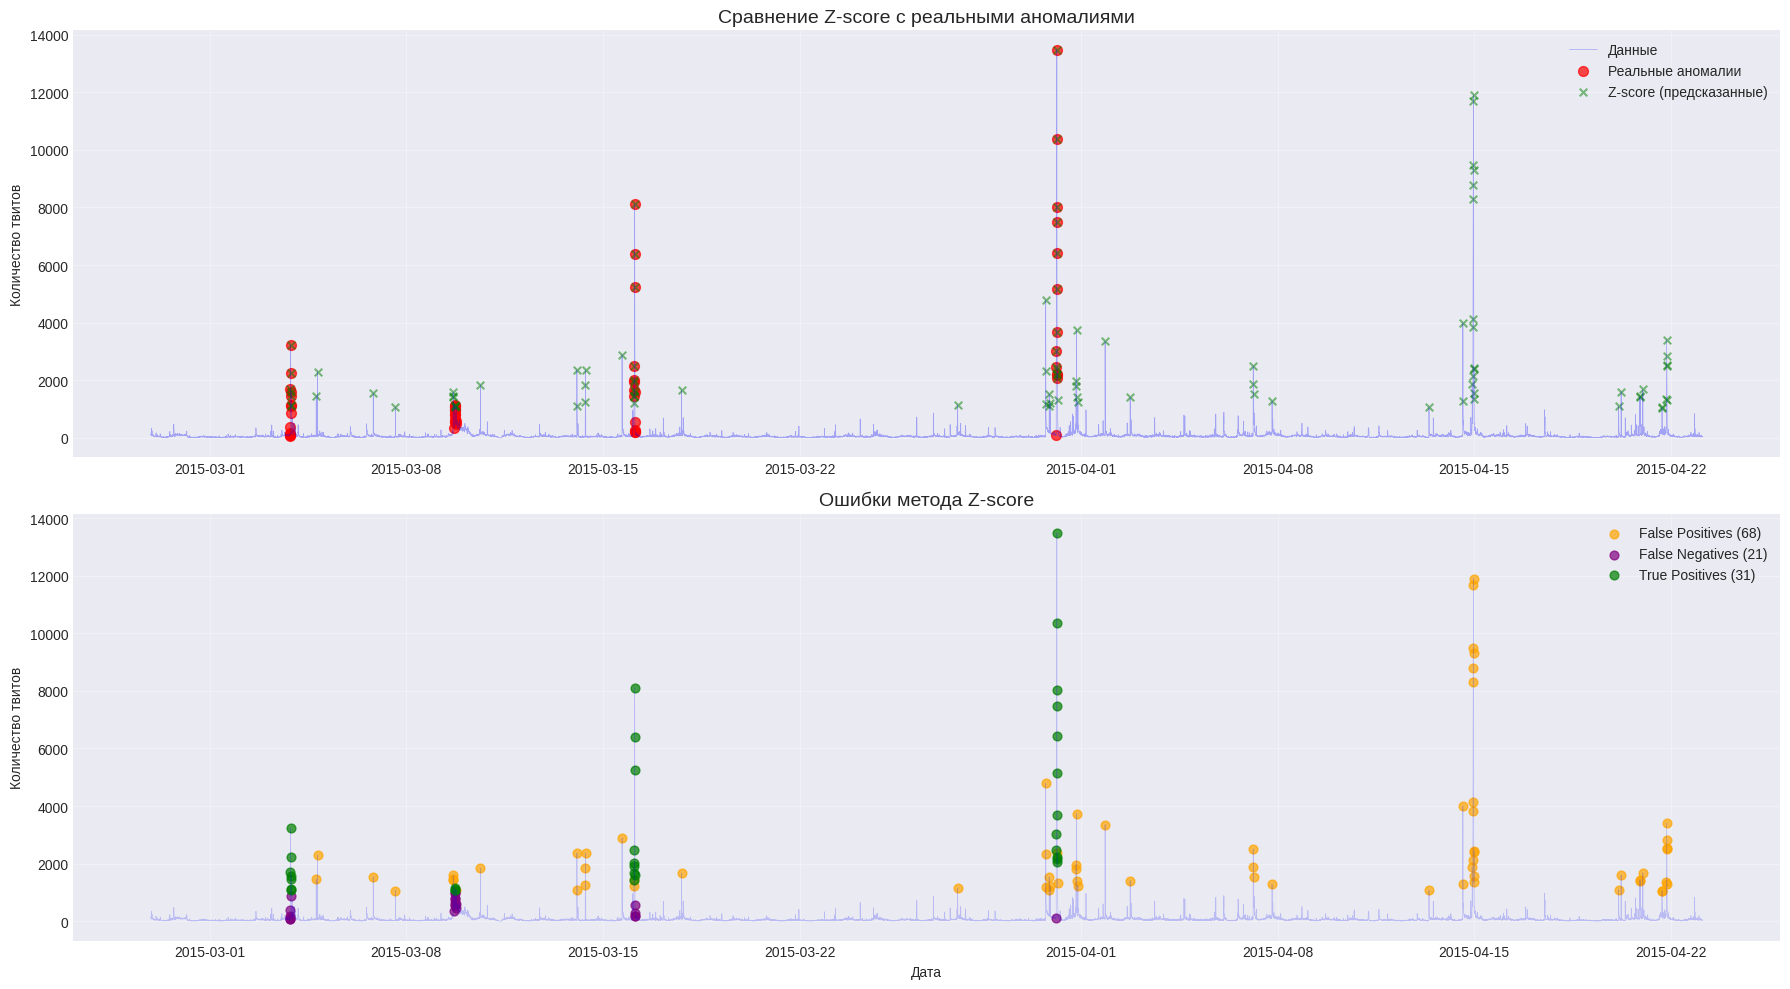



АНАЛИЗ РЕЗУЛЬТАТОВ:

1. РЕАЛЬНЫЕ АНОМАЛИИ:
   - Найдено 52 аномальных точек (с учетом окна в 30 минут)
   - Исходных аномальных точек в разметке: 4
   - Процент аномалий в данных: 0.33%

2. СРАВНЕНИЕ МЕТОДОВ:


   Z-score:
   - Precision: 31.31% (из всех найденных аномалий 31% реальные)
   - Recall: 59.62% (найдено 60% всех реальных аномалий)
   - F1-Score: 0.4106
   - TP: 31, FP: 68, FN: 21


   IQR:
   - Precision: 3.84% (из всех найденных аномалий 4% реальные)
   - Recall: 92.31% (найдено 92% всех реальных аномалий)
   - F1-Score: 0.0737
   - TP: 48, FP: 1202, FN: 4


   ARIMA error:
   - Precision: 13.02% (из всех найденных аномалий 13% реальные)
   - Recall: 48.08% (найдено 48% всех реальных аномалий)
   - F1-Score: 0.2049
   - TP: 25, FP: 167, FN: 27


3. ЛУЧШИЙ МЕТОД: Z-score
   - Причина: наивысший F1-Score (0.4106)
   - Precision: 31.31%
   - Recall: 59.62%

4. АНАЛИЗ ОШИБОК:
   - False Positives: 68 
     -> метод ошибочно определил нормальные значения как аномалии
   - Fal

In [16]:
# Загрузка файла разметки
from google.colab import files
uploaded = files.upload()
json_filename = list(uploaded.keys())[0]

# Загрузка JSON
with open(json_filename, 'r') as f:
    labels_data = json.load(f)

print(f"\nФайл разметки загружен: {json_filename}")

# Находим разметку для нашего файла
our_filename = None
for key in labels_data.keys():
    if "Twitter_volume_AAPL" in key:
        our_filename = key
        break

if our_filename:
    anomaly_data = labels_data[our_filename]
    print(f"\nНайдена разметка для {our_filename}")
    print(f"Тип данных: {type(anomaly_data)}")
    print(f"Количество аномальных точек: {len(anomaly_data)}")
    print(f"Аномальные моменты времени:")
    for i, ts in enumerate(anomaly_data[:10], 1):
        print(f"  {i}. {ts}")
    if len(anomaly_data) > 10:
        print(f"  ... и еще {len(anomaly_data) - 10} точек")

    # Это список отдельных временных меток (точечные аномалии)
    anomaly_timestamps = [pd.to_datetime(ts) for ts in anomaly_data]

else:
    print(f"\nРазметка для данных не найдена")
    anomaly_timestamps = []

# Создаем столбец с реальными аномалиями (точечные метки)
def is_anomaly_point(timestamp, anomaly_timestamps, window_minutes=30):
    """
    Проверяет, является ли точка аномальной.
    Если временная метка находится в пределах window_minutes от аномальной точки,
    считаем ее аномальной (с учетом погрешности временных меток)
    """
    for anomaly_ts in anomaly_timestamps:
        time_diff = abs((timestamp - anomaly_ts).total_seconds() / 60)
        if time_diff <= window_minutes:
            return 1
    return 0

# Создаем столбец с реальными метками
if anomaly_timestamps:
    series['true_anomaly'] = series['timestamp'].apply(
        lambda x: is_anomaly_point(x, anomaly_timestamps, window_minutes=30)
    )
else:
    print("Нет аномальных точек для разметки")
    series['true_anomaly'] = 0

print(f"\nРеальные аномалии в данных:")
print(f"Всего записей: {len(series)}")
print(f"Из них аномалий: {series['true_anomaly'].sum()}")
print(f"Процент аномалий: {series['true_anomaly'].sum()/len(series)*100:.2f}%")

# Визуализация реальных аномалий
if anomaly_timestamps:
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(series['timestamp'], series['value'], color='blue', alpha=0.5, linewidth=0.8, label='Данные')

    # Отмечаем аномальные точки
    ax.scatter(series[series['true_anomaly']==1]['timestamp'],
               series[series['true_anomaly']==1]['value'],
               color='red', s=50, label='Реальные аномалии (разметка)', alpha=0.7, marker='o')

    # Добавляем вертикальные линии для аномальных точек
    for ts in anomaly_timestamps:
        ax.axvline(x=ts, color='red', alpha=0.3, linestyle='--', linewidth=1)

    ax.set_title('Реальные аномалии в данных (из разметки NAB)', fontsize=14)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Количество твитов')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

# Сравнение методов с разметкой
if anomaly_timestamps and series['true_anomaly'].sum() > 0:
    methods = {
        'Z-score': 'anomaly_z',
        'IQR': 'anomaly_iqr',
        'ARIMA error': 'anomaly_arima'
    }

    results_evaluation = {}
    y_true = series['true_anomaly']

    for method_name, col_name in methods.items():
        if col_name not in series.columns:
            print(f"Столбец {col_name} не найден")
            continue

        y_pred = series[col_name].astype(int)

        # Расчет метрик
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        results_evaluation[method_name] = {
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'True Positives': ((y_true == 1) & (y_pred == 1)).sum(),
            'False Positives': ((y_true == 0) & (y_pred == 1)).sum(),
            'False Negatives': ((y_true == 1) & (y_pred == 0)).sum(),
            'True Negatives': ((y_true == 0) & (y_pred == 0)).sum()
        }

        print(f"\n{method_name}:")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")

    # Таблица сравнения
    if results_evaluation:
        eval_df = pd.DataFrame(results_evaluation).T
        print("\nСравнение методов обнаружения аномалий:")
        display(eval_df.round(4))

        # Confusion Matrix для всех методов
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for idx, (method_name, col_name) in enumerate(methods.items()):
            if col_name in series.columns:
                y_pred = series[col_name].astype(int)
                cm = confusion_matrix(y_true, y_pred)

                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                           xticklabels=['Normal', 'Anomaly'],
                           yticklabels=['Normal', 'Anomaly'],
                           ax=axes[idx])
                axes[idx].set_title(f'{method_name}')
                axes[idx].set_xlabel('Predicted')
                axes[idx].set_ylabel('Actual')

        plt.tight_layout()
        plt.show()

        # Детальный анализ лучшего метода
        best_method = max(results_evaluation, key=lambda x: results_evaluation[x]['F1-Score'])
        best_col = methods[best_method]

        print(f"\nЛучший метод по F1-Score: {best_method}")
        print(f"   F1-Score: {results_evaluation[best_method]['F1-Score']:.4f}")

        # Визуализация ошибок лучшего метода
        fig, axes = plt.subplots(2, 1, figsize=(18, 10))

        # График 1: Сравнение с реальными аномалиями
        axes[0].plot(series['timestamp'], series['value'], color='blue', alpha=0.3, linewidth=0.5, label='Данные')

        # Реальные аномалии
        axes[0].scatter(series[series['true_anomaly']==1]['timestamp'],
                        series[series['true_anomaly']==1]['value'],
                        color='red', s=50, label='Реальные аномалии', alpha=0.7, marker='o')

        # Предсказанные аномалии (лучший метод)
        y_pred_best = series[best_col].astype(int)
        axes[0].scatter(series[y_pred_best==1]['timestamp'],
                        series[y_pred_best==1]['value'],
                        color='green', s=30, label=f'{best_method} (предсказанные)', alpha=0.5, marker='x')

        axes[0].set_title(f'Сравнение {best_method} с реальными аномалиями', fontsize=14)
        axes[0].set_ylabel('Количество твитов')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # График 2: Ошибки метода
        # False Positives (ложная тревога)
        fp = series[(y_pred_best == 1) & (series['true_anomaly'] == 0)]
        axes[1].scatter(fp['timestamp'], fp['value'],
                       color='orange', s=40, label=f'False Positives ({len(fp)})', alpha=0.7)

        # False Negatives (пропущенные аномалии)
        fn = series[(y_pred_best == 0) & (series['true_anomaly'] == 1)]
        axes[1].scatter(fn['timestamp'], fn['value'],
                       color='purple', s=40, label=f'False Negatives ({len(fn)})', alpha=0.7)

        # True Positives
        tp = series[(y_pred_best == 1) & (series['true_anomaly'] == 1)]
        axes[1].scatter(tp['timestamp'], tp['value'],
                       color='green', s=40, label=f'True Positives ({len(tp)})', alpha=0.7)

        axes[1].plot(series['timestamp'], series['value'], color='blue', alpha=0.2, linewidth=0.5)
        axes[1].set_title(f'Ошибки метода {best_method}', fontsize=14)
        axes[1].set_xlabel('Дата')
        axes[1].set_ylabel('Количество твитов')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Итоги
        print("\n" + "=" * 60)

        print(f"""
АНАЛИЗ РЕЗУЛЬТАТОВ:

1. РЕАЛЬНЫЕ АНОМАЛИИ:
   - Найдено {series['true_anomaly'].sum()} аномальных точек (с учетом окна в 30 минут)
   - Исходных аномальных точек в разметке: {len(anomaly_timestamps)}
   - Процент аномалий в данных: {series['true_anomaly'].sum()/len(series)*100:.2f}%

2. СРАВНЕНИЕ МЕТОДОВ:
""")

        for method_name in results_evaluation:
            res = results_evaluation[method_name]
            print(f"""
   {method_name}:
   - Precision: {res['Precision']:.2%} (из всех найденных аномалий {res['Precision']:.0%} реальные)
   - Recall: {res['Recall']:.2%} (найдено {res['Recall']:.0%} всех реальных аномалий)
   - F1-Score: {res['F1-Score']:.4f}
   - TP: {res['True Positives']}, FP: {res['False Positives']}, FN: {res['False Negatives']}
""")

        print(f"""
3. ЛУЧШИЙ МЕТОД: {best_method}
   - Причина: наивысший F1-Score ({results_evaluation[best_method]['F1-Score']:.4f})
   - Precision: {results_evaluation[best_method]['Precision']:.2%}
   - Recall: {results_evaluation[best_method]['Recall']:.2%}

4. АНАЛИЗ ОШИБОК:
   - False Positives: {results_evaluation[best_method]['False Positives']}
     -> метод ошибочно определил нормальные значения как аномалии
   - False Negatives: {results_evaluation[best_method]['False Negatives']}
     -> метод пропустил реальные аномалии
""")
    else:
        print("\nНе удалось рассчитать метрики - нет данных для сравнения")
else:
    print("\nНет аномальных точек в разметке для оценки")

###СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ:

   МЕТОД Z-SCORE (F1-Score: 0.4106) - ЛУЧШИЙ
   + Precision 31.31%: из 99 найденных аномалий 31 действительно аномальные
   + Recall 59.62%: найдено почти 60% всех реальных аномалий
   + Хороший баланс между точностью и полнотой
   - 68 ложных тревог (False Positives)
   - 21 пропущенная аномалия (False Negatives)

   МЕТОД IQR (F1-Score: 0.0737) - ХУДШИЙ
   + Recall 92.31%: находит почти все реальные аномалии (48 из 52)
   - Precision всего 3.84%: огромное количество ложных тревог (1202!)
   - Слишком чувствителен, находит слишком много "аномалий"
   - Неприменим на практике из-за большого числа ложных срабатываний

   МЕТОД ОШИБКИ ARIMA (F1-Score: 0.2049) - СРЕДНИЙ
   + Precision 13.02%: лучше чем IQR, но хуже чем Z-score
   + Recall 48.08%: находит около половины аномалий
   - Пропускает больше аномалий чем другие методы
   - Средний баланс между точностью и полнотой

**ПОЧЕМУ Z-SCORE ЛУЧШИЙ:**
   Для данного типа данных (объем твитов) Z-score оказался наиболее эффективным,
   так как:
   - Аномалии в социальных медиа часто являются глобальными выбросами
   - Данные имеют высокую волатильность, но Z-score хорошо справляется с этим
   - Порог 3 сигмы дает хороший баланс между обнаружением и ложными тревогами
   

###ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ
   ДЛЯ РЕАЛЬНОГО МОНИТОРИНГА:
   - Использовать Z-score с порогом 3 как основной метод
   - Добавить ручную проверку для 68 ложных тревог (они могут быть полезны)
   - Настроить порог в зависимости от требуемого баланса:
     * Если важнее не пропустить аномалию -> снизить порог до 2.5
     * Если важнее избежать ложных тревог -> повысить порог до 3.5

   ДЛЯ КОМБИНИРОВАННОГО ПОДХОДА:
   - Использовать IQR для предварительного отбора (высокий Recall)
   - Затем применять Z-score для фильтрации (повышение Precision)
   - Это даст высокий Recall Z-score и лучшую Precision

# Интерпретация

### 1. ДАТАСЕТ И ПОКАЗАТЕЛЬ
- **Выбранный датасет**: NAB (Numenta Anomaly Benchmark)
- **Анализируемый показатель**: объем твитов по AAPL (количество упоминаний за 5 минут)
- **Период**: февраль-апрель 2015 года

### 2. ЭТАПЫ ПОДГОТОВКИ ДАННЫХ
1. Преобразование временных меток в формат datetime
2. Сортировка по времени
3. Проверка и обработка пропусков (заполнение предыдущим значением)
4. Удаление дубликатов
5. Масштабирование данных для моделей ML

### 3. ВИЗУАЛЬНЫЙ АНАЛИЗ
- Данные показывают высокую волатильность с резкими пиками
- Наблюдается несколько периодов повышенной активности
- Скользящее среднее (30 дней) сглаживает колебания и показывает общий тренд

### 4. ПРОГНОЗИРОВАНИЕ
**Базовая модель (Naive)**:
- MAE: 76.12, RMSE: 482.15
- Простой прогноз, но не учитывает паттерны данных

**Скользящее среднее (MA7)**:
- MAE: 75.92, RMSE: 481.25
- Немного лучше Naive, сглаживает шум

**ARIMA(2,1,2)**:
- MAE: 76.87, RMSE: 480.44
- Лучшая модель по RMSE
- Учитывает автокорреляцию в данных

### 5. ОБНАРУЖЕНИЕ АНОМАЛИЙ
**Методы и результаты**:
| Метод | Найдено аномалий | % от данных |
|-------|------------------|-------------|
| Z-score (порог=3) | 99 | 0.62% |
| IQR | 1250 | 7.86% |
| Ошибка ARIMA | 192 | 1.21% |

**Сравнение методов**:
- **Z-score**: Выявляет глобальные выбросы
- **IQR**: Более консервативный, находит больше аномалий, но может быть слишком чувствительным
- **Ошибка ARIMA**: Находит моменты, когда поведение ряда отклоняется от прогноза

### 6. ПРАКТИЧЕСКОЕ ПРИМЕНЕНИЕ
Разработанный прототип может использоваться для:
- **Мониторинга социальных медиа**: выявление вирусных трендов
- **Финансового анализа**: предсказание влияния новостей на рынок
- **PR-аналитики**: оценка эффективности маркетинговых кампаний
- **Систем раннего предупреждения**: обнаружение нештатных ситуаций

### 7. ОГРАНИЧЕНИЯ
1. Модели не учитывают внешние факторы (день недели, праздники, новости)
2. Методы обнаружения аномалий используют простые статистические пороги
3. ARIMA не учитывает сезонность на уровне дней недели
4. Данные только по одной компании, нет сравнения с конкурентами

### 8. ПРЕДЛОЖЕНИЯ ПО УЛУЧШЕНИЮ
1. **Модели прогнозирования**:
   - Добавить SARIMA для учета сезонности (недельная, дневная)
   - Использовать LSTM для долгосрочного прогнозирования
   - Включить дополнительные признаки (время суток, день недели)

2. **Обнаружение аномалий**:
   - Использовать Z-score с порогом 3 как основной метод
   - Использовать IQR для предварительного отбора (высокий Recall), затем применять Z-score для фильтрации (повышение Precision)
   - Автоматический подбор порогов (например, с использованием статистических тестов)
   - Использование Isolation Forest и других ML-методов
   - Ансамблирование методов для повышения точности

3. **Визуализация и UI**:
   - Создать интерактивный дашборд с помощью Plotly или Streamlit
   - Добавить возможность выбора компаний для сравнения
   - Реализовать систему оповещений при обнаружении аномалий

4. **Данные**:
   - Использовать несколько компаний для сравнительного анализа
   - Добавить внешние признаки (новостные заголовки, финансовые отчеты)
   - Увеличить период данных для лучшего обучения моделей

#Выводы
Ключевые выводы
- ARIMA показала наилучшие результаты прогнозирования благодаря учету автокорреляции

- Z-score эффективно выявляет глобальные выбросы в данных

- IQR находит больше аномалий, но может быть излишне чувствительным

- Ошибка ARIMA хорошо определяет моменты нестандартного поведения

Возможные улучшения
- Использование SARIMA для учета сезонности

- Применение LSTM для долгосрочного прогнозирования

- Автоматический подбор порогов для обнаружения аномалий

- Создание интерактивного дашборда